# 1. Import Library

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# 2. Memuat Dataset dan Melakukan Exploratory Data Analysis

In [117]:
df = pd.read_csv('./data/bank_transactions_data_edited.csv')
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [118]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   str    
 1   AccountID                2516 non-null   str    
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   str    
 4   TransactionType          2507 non-null   str    
 5   Location                 2507 non-null   str    
 6   DeviceID                 2507 non-null   str    
 7   IP Address               2517 non-null   str    
 8   MerchantID               2514 non-null   str    
 9   Channel                  2510 non-null   str    
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   str    
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance           2510 non-n

In [152]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2490.00000,2498.000000,2490.000000,2495.000000,2489.000000
mean,297.74190,44.644916,119.546185,1.122645,5117.506557
std,292.47931,17.818558,69.984109,0.596861,3897.549099
min,0.26000,18.000000,10.000000,1.000000,101.250000
25%,81.39000,27.000000,63.000000,1.000000,1504.990000
50%,211.36000,45.000000,112.500000,1.000000,4737.840000
75%,411.67000,59.000000,161.000000,1.000000,7677.760000
max,1919.11000,80.000000,300.000000,5.000000,14977.990000


# 3. Pembersihan dan Pra Pemrosesan Data

In [149]:
# Cek missing values
print("\nMissing values per fitur:")
print(df.isnull().sum())


Missing values per fitur:
TransactionID              29
AccountID                  21
TransactionAmount          26
TransactionDate            28
TransactionType            30
Location                   30
DeviceID                   30
IP Address                 20
MerchantID                 23
Channel                    27
CustomerAge                18
CustomerOccupation         23
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
PreviousTransactionDate    24
dtype: int64


In [169]:
df = df.dropna()

# Cek missing values
print("\nMissing values per fitur setelah di drop:")
print(df.isnull().sum())


Missing values per fitur setelah di drop:
TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64


In [170]:
# Mengidentifikasi baris duplikat
duplicates = df.duplicated()
 
print("Baris duplikat:")
print(df[duplicates])

Baris duplikat:
Empty DataFrame
Columns: [TransactionID, AccountID, TransactionAmount, TransactionDate, TransactionType, Location, DeviceID, IP Address, MerchantID, Channel, CustomerAge, CustomerOccupation, TransactionDuration, LoginAttempts, AccountBalance, PreviousTransactionDate]
Index: []


In [171]:
# Menghapus baris duplikat
df = df.drop_duplicates()
 
print("DataFrame setelah menghapus duplikat:")
print(df)

DataFrame setelah menghapus duplikat:
     TransactionID AccountID  TransactionAmount      TransactionDate  \
0         TX000001   AC00128              14.09  2023-04-11 16:29:14   
1         TX000002   AC00455             376.24  2023-06-27 16:44:19   
2         TX000003   AC00019             126.29  2023-07-10 18:16:08   
3         TX000004   AC00070             184.50  2023-05-05 16:32:11   
5         TX000006   AC00393              92.15  2023-04-03 17:15:01   
...            ...       ...                ...                  ...   
2510      TX002511   AC00118             185.97  2023-02-24 16:24:46   
2511      TX002512   AC00009             243.08  2023-02-14 16:21:23   
2523      TX001691   AC00442              12.18  2023-04-20 18:50:39   
2524      TX000076   AC00239             232.12  2023-12-28 17:31:03   
2535      TX000592   AC00057             198.62  2023-05-15 16:19:14   

     TransactionType       Location DeviceID       IP Address MerchantID  \
0              Debit 

In [172]:
# List kolom yang ingin dibuang sesuai permintaan sebelumnya
kolom_dibuang = [
    'TransactionID', 'AccountID', 'DeviceID', 'IP Address', 'MerchantID', 
    'TransactionDate', 'PreviousTransactionDate', 'LoginAttempts'
]
# 1. Membuang kolom yang tidak digunakan
df_clean = df.drop(columns=kolom_dibuang, errors='ignore')
df_clean.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,AccountBalance
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,5112.21
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,13758.91
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1122.35
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,8569.06
5,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,781.68


In [173]:
category_features = df_clean.select_dtypes(include=['object']).columns
df_clean[category_features]

C:\Users\Rafly\AppData\Local\Temp\ipykernel_33720\2394542925.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  category_features = df_clean.select_dtypes(include=['object']).columns


,TransactionType,Location,Channel,CustomerOccupation
0,Debit,San Diego,ATM,Doctor
1,Debit,Houston,ATM,Doctor
2,Debit,Mesa,Online,Student
3,Debit,Raleigh,Online,Student
5,Debit,Oklahoma City,ATM,Student
...,...,...,...,...
2510,Debit,Denver,Online,Student
2511,Credit,Jacksonville,Online,Student
2523,Debit,New York,Branch,Retired
2524,Debit,Omaha,ATM,Engineer


In [174]:
# Inisialisasi LabelEncoder
label_encoder = LabelEncoder()
df_lencoder = pd.DataFrame(df_clean)
 
for col in category_features:
    df_lencoder[col] = label_encoder.fit_transform(df_clean[col])
 
# Menampilkan hasil
df_lencoder

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,AccountBalance
0,14.09,1,36,0,70.0,0,81.0,5112.21
1,376.24,1,15,0,68.0,0,141.0,13758.91
2,126.29,1,23,2,19.0,3,56.0,1122.35
3,184.50,1,33,2,26.0,3,25.0,8569.06
5,92.15,1,28,0,18.0,3,172.0,781.68
...,...,...,...,...,...,...,...,...
2510,185.97,1,10,2,23.0,3,19.0,1776.91
2511,243.08,0,17,2,24.0,3,93.0,131.25
2523,12.18,1,27,1,76.0,2,77.0,4909.24
2524,232.12,1,29,0,37.0,1,51.0,6689.87


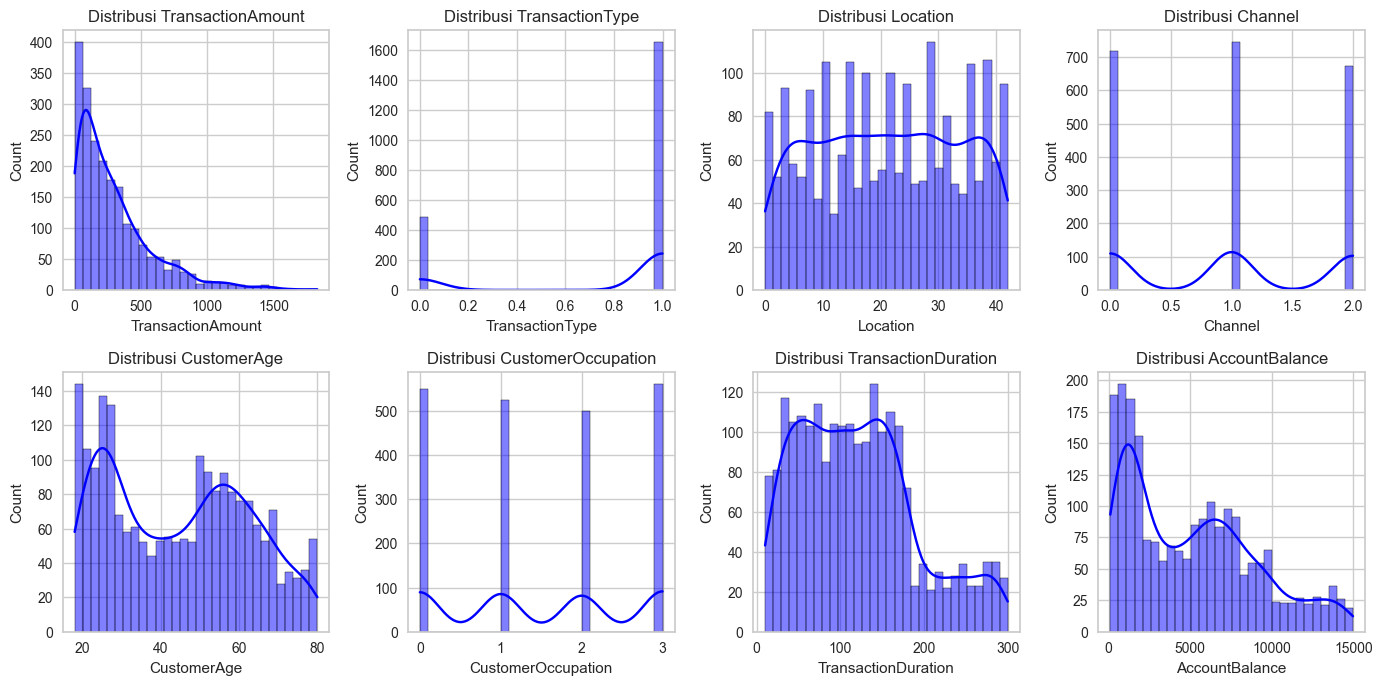

In [175]:
# Distribusi fitur numerik
num_features = df_lencoder.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
for i, column in enumerate(num_features.columns, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df_lencoder[column], bins=30, kde=True, color='blue')
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

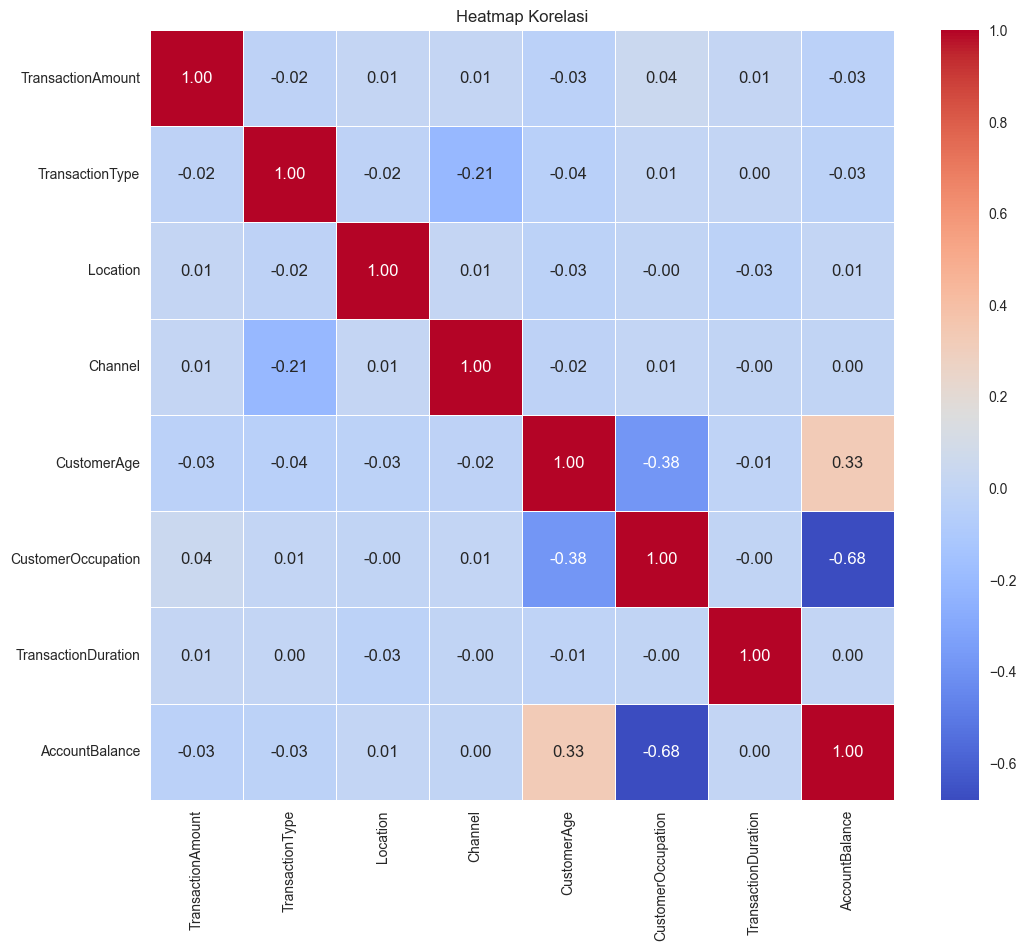

In [176]:
# Heatmap korelasi untuk fitur numerik
plt.figure(figsize=(12, 10))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

# 4. Membangun Model Clustering

In [183]:
X = df_lencoder.values


# Menampilkan data yang diambil dalam format DataFrame dengan nama kolom yang sesuai
print(pd.DataFrame(X, columns=['Transaction Amount (k$)', 'Transaction Type', 'Location', 'Channel', 'Customer Age', 'Customer Occupation', 'Duration (Second)', 'Balance (k$)']))

      Transaction Amount (k$)  Transaction Type  Location  Channel  \
0                       14.09               1.0      36.0      0.0   
1                      376.24               1.0      15.0      0.0   
2                      126.29               1.0      23.0      2.0   
3                      184.50               1.0      33.0      2.0   
4                       92.15               1.0      28.0      0.0   
...                       ...               ...       ...      ...   
2130                   185.97               1.0      10.0      2.0   
2131                   243.08               0.0      17.0      2.0   
2132                    12.18               1.0      27.0      1.0   
2133                   232.12               1.0      29.0      0.0   
2134                   198.62               0.0      40.0      1.0   

      Customer Age  Customer Occupation  Duration (Second)  Balance (k$)  
0             70.0                  0.0               81.0       5112.21  
1        

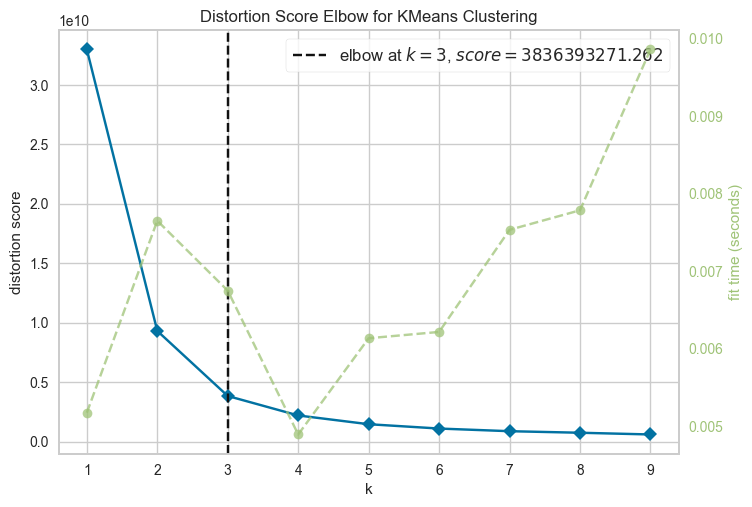

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [184]:

# Inisialisasi model KMeans tanpa parameter awal
kmeans = KMeans()
 
# Inisialisasi visualizer KElbow untuk menentukan jumlah cluster optimal
visualizer = KElbowVisualizer(kmeans, k=(1, 10), force_model=True)
 
# Fit visualizer dengan data untuk menemukan jumlah cluster optimal
visualizer.fit(X)
 
# Menampilkan grafik elbow untuk analisis
visualizer.show()

In [186]:
# Mendapatkan jumlah cluster (kita gunakan 3 sesuai permintaan Anda di kode ini)
k = 3

# Inisialisasi dan melatih model KMeans dengan jumlah cluster = k
kmeans = KMeans(n_clusters=k, random_state=0)
kmeans.fit(X)

# Mendapatkan label cluster
labels = kmeans.labels_

# Fungsi untuk analisis karakteristik cluster
def analyze_clusters(X, labels, k):
    print("Analisis Karakteristik Setiap Cluster:")
    for cluster_id in range(k):
        # Mengambil data untuk cluster saat ini
        cluster_data = X[labels == cluster_id]

        # Menghitung rata-rata untuk setiap fitur dalam cluster berdasarkan urutan kolom
        mean_tr_amount = cluster_data[:, 0].mean()   # 1. Transaction Amount (k$)
        mean_tr_type = cluster_data[:, 1].mean()     # 2. Transaction Type
        mean_location = cluster_data[:, 2].mean()    # 3. Location
        mean_channel = cluster_data[:, 3].mean()     # 4. Channel
        mean_age = cluster_data[:, 4].mean()         # 5. Customer Age
        mean_occupation = cluster_data[:, 5].mean()  # 6. Customer Occupation
        mean_duration = cluster_data[:, 6].mean()    # 7. Duration (Second)
        mean_balance = cluster_data[:, 7].mean()     # 8. Balance (k$)

        print(f"\nCluster {cluster_id + 1}:")
        print(f"Rata-rata Transaction Amount (k$): {mean_tr_amount:.2f}")
        print(f"Rata-rata Transaction Type: {mean_tr_type:.2f}")
        print(f"Rata-rata Location: {mean_location:.2f}")
        print(f"Rata-rata Channel: {mean_channel:.2f}")
        print(f"Rata-rata Customer Age: {mean_age:.2f}")
        print(f"Rata-rata Customer Occupation: {mean_occupation:.2f}")
        print(f"Rata-rata Duration (Second): {mean_duration:.2f}")
        print(f"Rata-rata Balance (k$): {mean_balance:.2f}")
        print("-" * 40)

# Analisis karakteristik setiap cluster
analyze_clusters(X, labels, k)

Analisis Karakteristik Setiap Cluster:

Cluster 1:
Rata-rata Transaction Amount (k$): 281.06
Rata-rata Transaction Type: 0.78
Rata-rata Location: 20.60
Rata-rata Channel: 1.00
Rata-rata Customer Age: 51.51
Rata-rata Customer Occupation: 1.22
Rata-rata Duration (Second): 117.78
Rata-rata Balance (k$): 6513.54
----------------------------------------

Cluster 2:
Rata-rata Transaction Amount (k$): 310.95
Rata-rata Transaction Type: 0.78
Rata-rata Location: 21.52
Rata-rata Channel: 0.96
Rata-rata Customer Age: 37.95
Rata-rata Customer Occupation: 2.20
Rata-rata Duration (Second): 120.60
Rata-rata Balance (k$): 1586.40
----------------------------------------

Cluster 3:
Rata-rata Transaction Amount (k$): 299.57
Rata-rata Transaction Type: 0.75
Rata-rata Location: 21.92
Rata-rata Channel: 0.98
Rata-rata Customer Age: 48.04
Rata-rata Customer Occupation: 0.22
Rata-rata Duration (Second): 124.00
Rata-rata Balance (k$): 11585.28
----------------------------------------


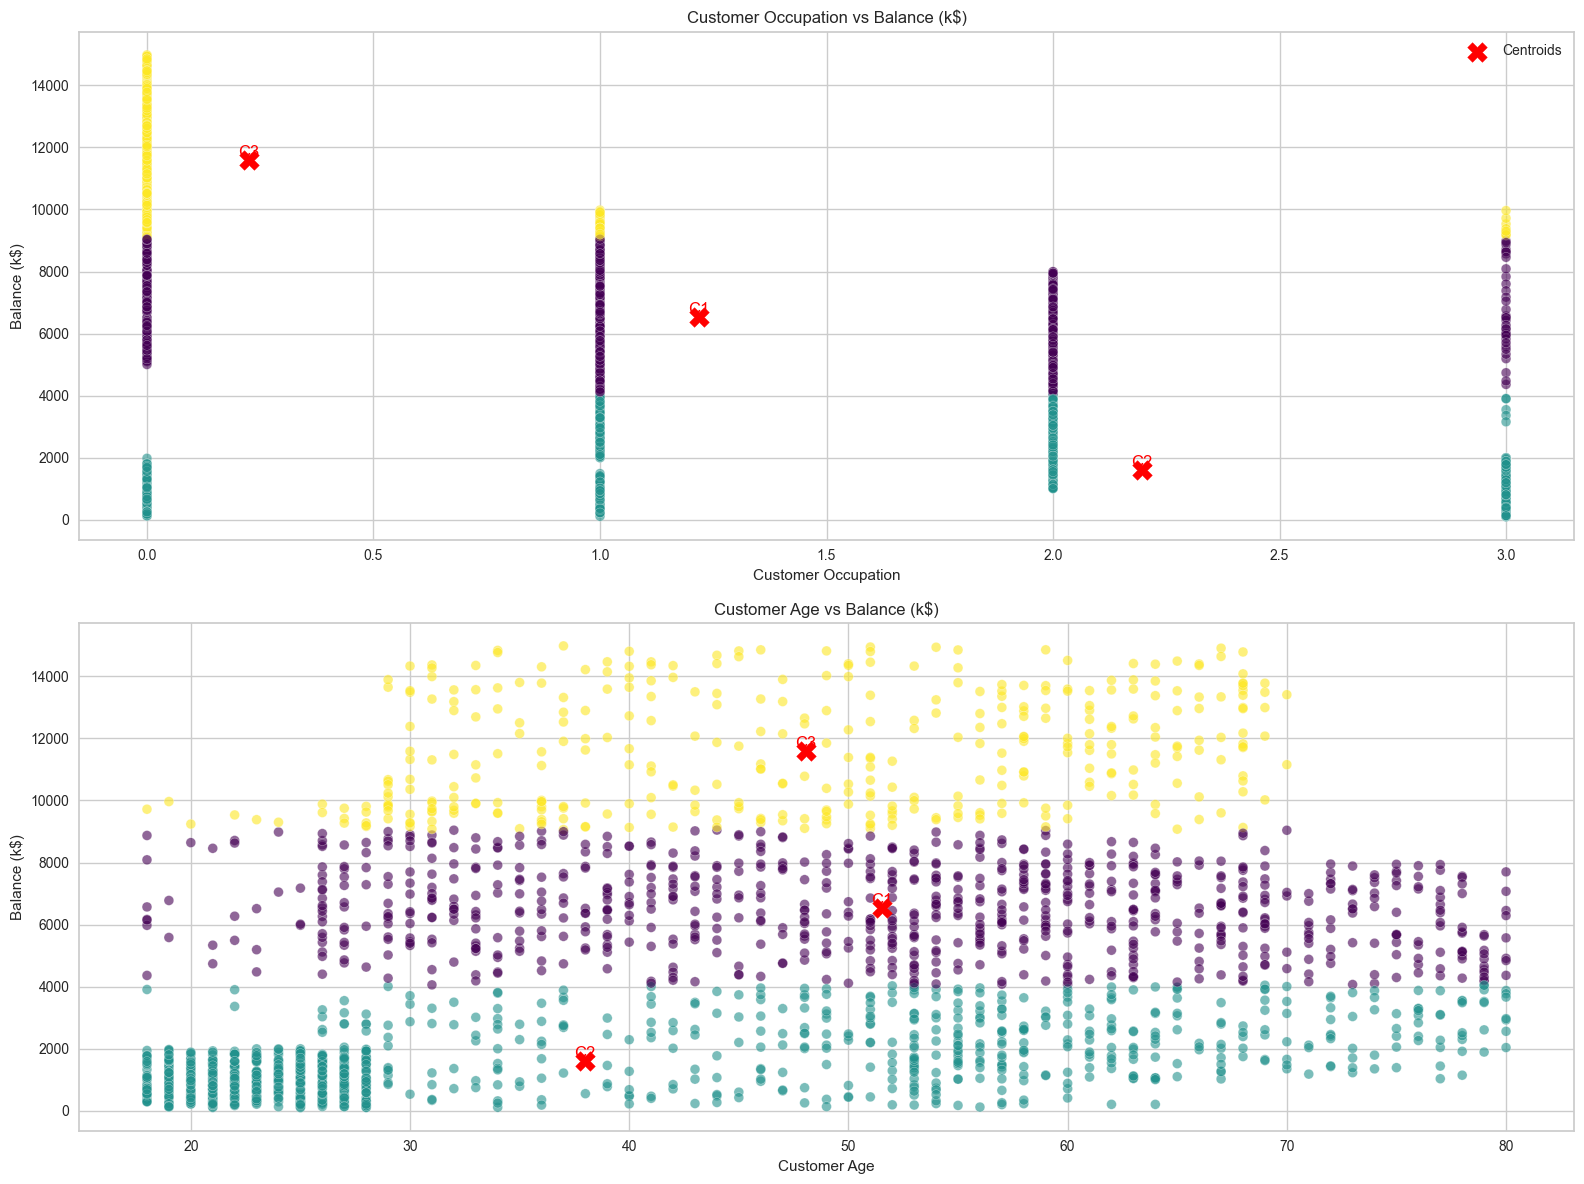

Nilai Centroids (Skala Data X):
------------------------------------------------------------
Centroid 1:
  - Transaction Amount (k$): 281.2943
  - Transaction Type: 0.7799
  - Location: 20.6075
  - Channel: 1.0039
  - Customer Age: 51.5302
  - Customer Occupation: 1.2175
  - Duration (Second): 117.8687
  - Balance (k$): 6519.8677
------------------------------------------------------------
Centroid 2:
  - Transaction Amount (k$): 310.7010
  - Transaction Type: 0.7764
  - Location: 21.5106
  - Channel: 0.9607
  - Customer Age: 37.9607
  - Customer Occupation: 2.1964
  - Duration (Second): 120.5247
  - Balance (k$): 1591.3780
------------------------------------------------------------
Centroid 3:
  - Transaction Amount (k$): 299.5715
  - Transaction Type: 0.7507
  - Location: 21.9205
  - Channel: 0.9753
  - Customer Age: 48.0438
  - Customer Occupation: 0.2247
  - Duration (Second): 124.0027
  - Balance (k$): 11585.2764
------------------------------------------------------------


In [196]:

# Mendapatkan posisi centroid dari model
centroids = kmeans.cluster_centers_

# Daftar nama fitur berdasarkan urutan indeks Anda (0 sampai 7)
feature_names = [
    'Transaction Amount (k$)', # 0
    'Transaction Type',        # 1
    'Location',                # 2
    'Channel',                 # 3
    'Customer Age',            # 4
    'Customer Occupation',     # 5
    'Duration (Second)',       # 6
    'Balance (k$)'             # 7
]

# Menentukan kombinasi indeks berdasarkan temuan Heatmap Korelasi terbaik
variasi_plot = [
    (5, 7),  # Index 5 (Occupation) vs Index 7 (Balance)   -> Korelasi: -0.68
    (4, 7),  # Index 4 (Age) vs Index 7 (Balance)          -> Korelasi:  0.33
]

# (Sisa kode di bawahnya tetap sama persis seperti sebelumnya)
# Membuat figure dan axis untuk 2 grafik (2 baris, 1 kolom)
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
axes = axes.flatten() # Meratakan array axis agar mudah di-loop

# Looping untuk menggambar setiap variasi grafik
for i, (idx_x, idx_y) in enumerate(variasi_plot):
    ax = axes[i]
    
    # Plot data persebaran
    scatter = ax.scatter(X[:, idx_x], X[:, idx_y], c=labels, cmap='viridis', s=50, alpha=0.6, edgecolors='w', marker='o')
    
    # Plot centroid
    ax.scatter(centroids[:, idx_x], centroids[:, idx_y], c='red', s=200, marker='X', label='Centroids')
    
    # Menambahkan label pada centroid
    for j, centroid in enumerate(centroids):
        ax.text(centroid[idx_x], centroid[idx_y], f'C{j+1}', color='red', fontsize=12, ha='center', va='bottom')
    
    # Menambahkan judul dan label sumbu
    ax.set_title(f'{feature_names[idx_x]} vs {feature_names[idx_y]}')
    ax.set_xlabel(feature_names[idx_x])
    ax.set_ylabel(feature_names[idx_y])

# Menambahkan legenda pada grafik pertama
axes[0].legend()

# Merapikan jarak antar grafik dan menampilkannya
plt.tight_layout()
plt.show()

# =====================================================================
# Menampilkan nilai centroid lengkap untuk 8 fitur
# =====================================================================
print("Nilai Centroids (Skala Data X):")
print("-" * 60)
for i, centroid in enumerate(centroids):
    print(f"Centroid {i+1}:")
    for j, name in enumerate(feature_names):
        print(f"  - {name}: {centroid[j]:.4f}")
    print("-" * 60)

In [199]:
import joblib

# Asumsi variabel model Anda bernama 'kmeans'
# Simpan model tersebut ke dalam file
joblib.dump(kmeans, 'model_clustering.h5')

print("Model berhasil disimpan!")

Model berhasil disimpan!
